In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\traffic.csv\traffic.csv")

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 226278
Columns: 9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [5]:
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [6]:
df.isnull().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 103711


In [8]:
df = df.drop_duplicates()

print("Rows after cleaning:", len(df))

Rows after cleaning: 122567


In [9]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [11]:
df['date'].head()

0   2021-08-21
2   2021-08-21
3   2021-08-21
4   2021-08-21
5   2021-08-21
Name: date, dtype: datetime64[ns]

In [12]:
total_events = len(df)

unique_links = df['linkid'].nunique()

unique_countries = df['country'].nunique()

unique_cities = df['city'].nunique()

print("Total Events:", total_events)
print("Unique Links:", unique_links)
print("Unique Countries:", unique_countries)
print("Unique Cities:", unique_cities)

Total Events: 122567
Unique Links: 3839
Unique Countries: 211
Unique Cities: 11993


In [13]:
kpi = pd.DataFrame({
    'Metric': [
        'Total Events',
        'Unique Links',
        'Unique Countries',
        'Unique Cities'
    ],
    
    'Value': [
        total_events,
        unique_links,
        unique_countries,
        unique_cities
    ]
})

kpi

,Metric,Value
0,Total Events,122567
1,Unique Links,3839
2,Unique Countries,211
3,Unique Cities,11993


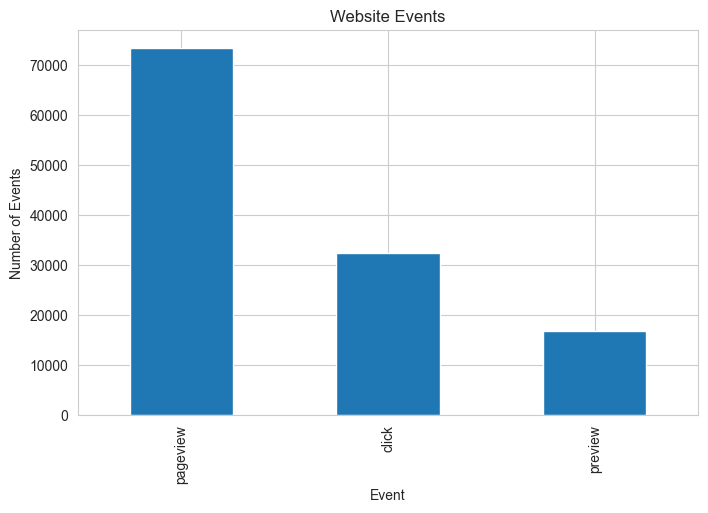

In [14]:
plt.figure(figsize=(8,5))

df['event'].value_counts().plot(kind='bar')

plt.title("Website Events")
plt.xlabel("Event")
plt.ylabel("Number of Events")

plt.show()

### Insight

The most common event represents the main type of activity in the dataset.
This indicates which type of user interaction occurs most frequently.

In [15]:
daily_traffic = df.groupby('date').size()

daily_traffic.head()

date
2021-08-19    21156
2021-08-20    18536
2021-08-21    16701
2021-08-22    16927
2021-08-23    16415
dtype: int64

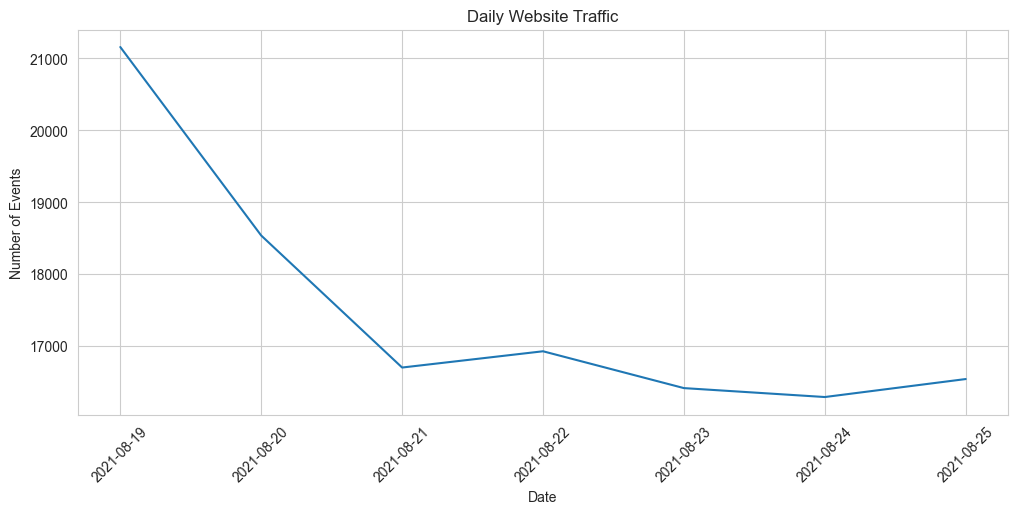

In [16]:
plt.figure(figsize=(12,5))

plt.plot(daily_traffic.index, daily_traffic.values)

plt.title("Daily Website Traffic")
plt.xlabel("Date")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)

plt.show()

In [17]:
top_countries = df['country'].value_counts().head(10)

top_countries

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
Name: count, dtype: int64

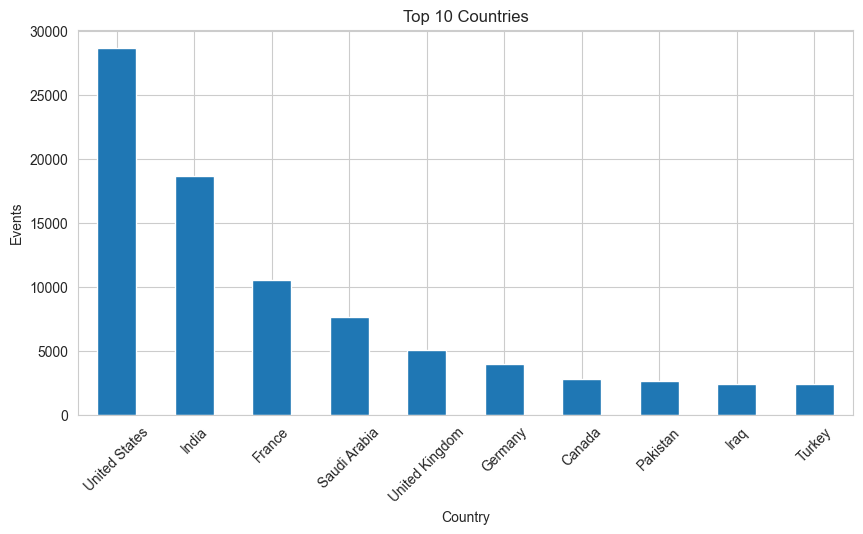

In [18]:
plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Events")

plt.xticks(rotation=45)

plt.show()

In [19]:
top_cities = df['city'].value_counts().head(10)

top_cities

city
Unknown        8797
Jeddah         2497
Riyadh         2232
Hyderabad      1088
Dammam         1002
Delhi           884
Jaipur          849
Lucknow         837
Kuwait City     816
Ahmedabad       808
Name: count, dtype: int64

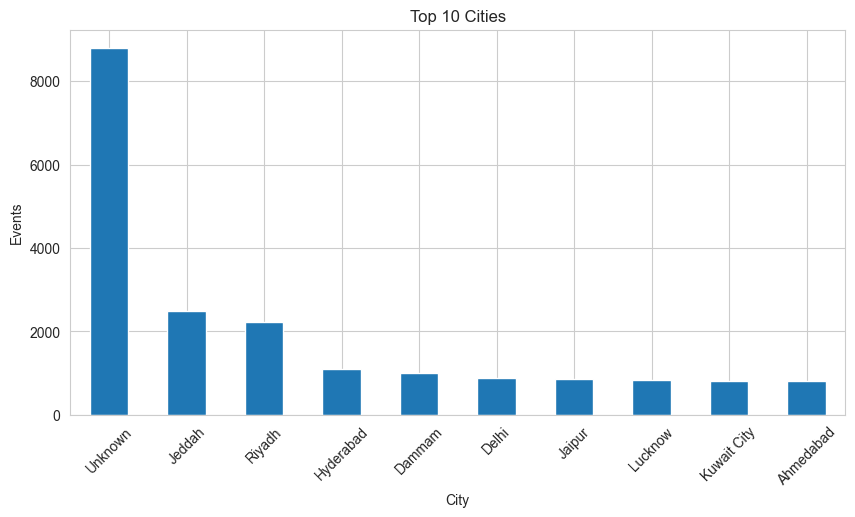

In [20]:
plt.figure(figsize=(10,5))

top_cities.plot(kind='bar')

plt.title("Top 10 Cities")
plt.xlabel("City")
plt.ylabel("Events")

plt.xticks(rotation=45)

plt.show()

In [21]:
top_artists = df['artist'].value_counts().head(10)

top_artists

artist
Tesher                                                          8288
Anne-Marie                                                      4029
Tundra Beats                                                    3951
Roddy Ricch                                                     3107
Olivia Rodrigo                                                  3037
Surf Mesa, Emilee                                               2956
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2675
PinkPantheress                                                  2446
50 Cent, Olivia                                                 2390
Name: count, dtype: int64

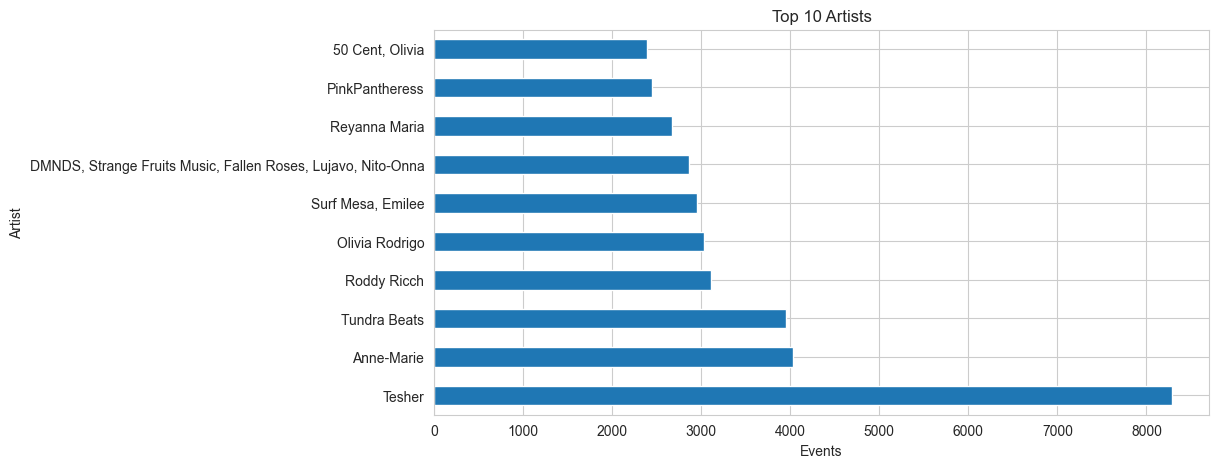

In [22]:
plt.figure(figsize=(10,5))

top_artists.plot(kind='barh')

plt.title("Top 10 Artists")
plt.xlabel("Events")
plt.ylabel("Artist")

plt.show()

In [24]:
journey = (
    df.sort_values(['linkid', 'date'])
      .groupby(['linkid', 'date'])['event']
      .agg(['first', 'last', 'count'])
      .reset_index()
)

journey.head()

,linkid,date,first,last,count
0,00073307-ae96-5089-a117-4783afb42f8e,2021-08-19,pageview,pageview,1
1,00073307-ae96-5089-a117-4783afb42f8e,2021-08-20,pageview,pageview,1
2,00126b32-0c35-507b-981c-02c80d2aa8e7,2021-08-19,click,pageview,4
3,0018cfff-50a1-5984-9715-01ef2d11a49a,2021-08-19,pageview,pageview,1
4,0033934b-5d16-5a06-af58-d087bcdd3680,2021-08-19,pageview,pageview,1


In [25]:
journey.columns = [
    'linkid',
    'date',
    'entry_event',
    'exit_event',
    'event_count'
]

journey.head()

,linkid,date,entry_event,exit_event,event_count
0,00073307-ae96-5089-a117-4783afb42f8e,2021-08-19,pageview,pageview,1
1,00073307-ae96-5089-a117-4783afb42f8e,2021-08-20,pageview,pageview,1
2,00126b32-0c35-507b-981c-02c80d2aa8e7,2021-08-19,click,pageview,4
3,0018cfff-50a1-5984-9715-01ef2d11a49a,2021-08-19,pageview,pageview,1
4,0033934b-5d16-5a06-af58-d087bcdd3680,2021-08-19,pageview,pageview,1


In [26]:
journey['entry_event'].value_counts()

entry_event
click       4239
pageview    2137
preview      187
Name: count, dtype: int64

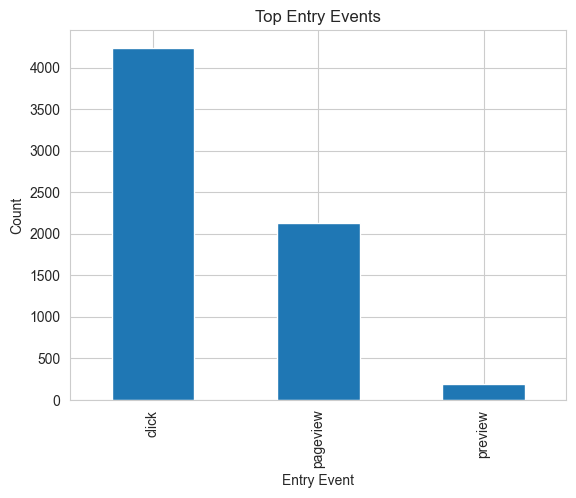

In [27]:
journey['entry_event'].value_counts().plot(kind='bar')

plt.title("Top Entry Events")
plt.xlabel("Entry Event")
plt.ylabel("Count")

plt.show()

In [28]:
journey['exit_event'].value_counts()

exit_event
pageview    6554
click          8
preview        1
Name: count, dtype: int64

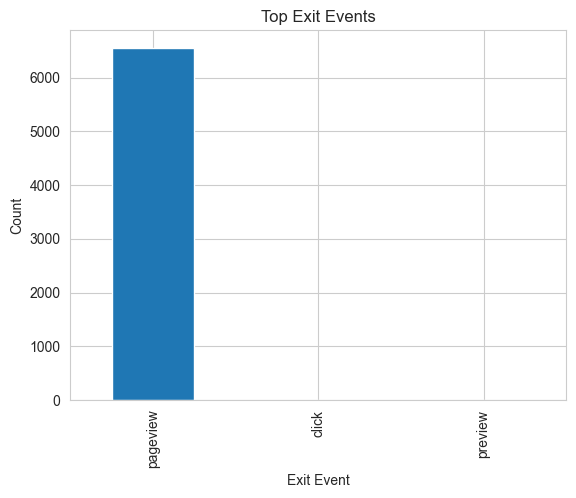

In [29]:
journey['exit_event'].value_counts().plot(kind='bar')

plt.title("Top Exit Events")
plt.xlabel("Exit Event")
plt.ylabel("Count")

plt.show()